# N3 · Censored Demand — "We stock out of euros every Friday"

**Panel question** — asked by the **Head of Data** and the **Head of
Product** together: *"Branch data shows we stock out of euros every Friday in
summer. Pricing or ops problem?"*

The senior insight, in one line: **recorded sales at a stocked-out branch are
censored, not demand** — and a forecast trained on them enters the
*spiral-down*: under-forecast → under-stock → more censoring → worse
forecast. This notebook demonstrates the spiral on known ground truth,
arrests it with a censored-likelihood fit, and only *then* touches pricing.

**Contract:** known Friday demand → naive forecast under-reads it → spiral
shown → censored MLE recovers truth → spiral arrested → pricing last.

In [1]:
# %matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize

from _style import C, apply_style
apply_style()
rng = np.random.default_rng(3)

# --- Ground truth: one branch's daily euro demand (log-normal by weekday) ----
DOW = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
MU = np.log(np.array([14, 13, 14, 17, 30, 24, 9]) * 1000)   # median £/day
SIGMA = 0.45
true_mean = np.exp(MU + SIGMA**2 / 2)
print("True mean daily euro demand (£k):",
      dict(zip(DOW, (true_mean / 1000).round(1))))

def draw_demand(dow, r):
    return r.lognormal(MU[dow], SIGMA)

True mean daily euro demand (£k): {'Mon': np.float64(15.5), 'Tue': np.float64(14.4), 'Wed': np.float64(15.5), 'Thu': np.float64(18.8), 'Fri': np.float64(33.2), 'Sat': np.float64(26.6), 'Sun': np.float64(10.0)}


## 1. The naive read: forecast on recorded sales

The replenishment policy stocks `1.05 × trailing mean of same-weekday SALES`.
When Friday demand exceeds stock, the till records the stock, not the demand.
Run 30 weeks and watch the spiral.

In [2]:
WEEKS = 30
history = []                       # (week, dow, stock, sales, stockout)
stock = true_mean * 1.0            # week 0: stocked off the TRUE mean

for w in range(WEEKS):
    for d in range(7):
        dem = draw_demand(d, rng)
        sales = min(dem, stock[d])
        history.append((w, d, stock[d], sales, dem > stock[d], dem))
    h = pd.DataFrame(history, columns=["week", "dow", "stock", "sales", "out", "demand"])
    trail = h[h.week > w - 4].groupby("dow")["sales"].mean()   # naive: sales = demand
    stock = (1.05 * trail).to_numpy()

h = pd.DataFrame(history, columns=["week", "dow", "stock", "sales", "out", "demand"])
fri = h[h.dow == 4]
print(f"Friday stockout rate, weeks  1-5  : {fri[fri.week < 5]['out'].mean():.0%}")
print(f"Friday stockout rate, weeks 16-30 : {fri[fri.week >= 15]['out'].mean():.0%}")
print(f"Friday stock, week 1 -> week 30  : £{fri.iloc[0].stock/1000:.0f}k -> "
      f"£{fri.iloc[-1].stock/1000:.0f}k   (true mean demand £{true_mean[4]/1000:.0f}k)")

Friday stockout rate, weeks  1-5  : 60%
Friday stockout rate, weeks 16-30 : 87%
Friday stock, week 1 -> week 30  : £33k -> £21k   (true mean demand £33k)


## 2. The spiral, drawn

This chart is the weapon: the policy quietly walks Friday stock *down* while
true demand never moved. Every week of censored data makes the forecast more
confident and more wrong.

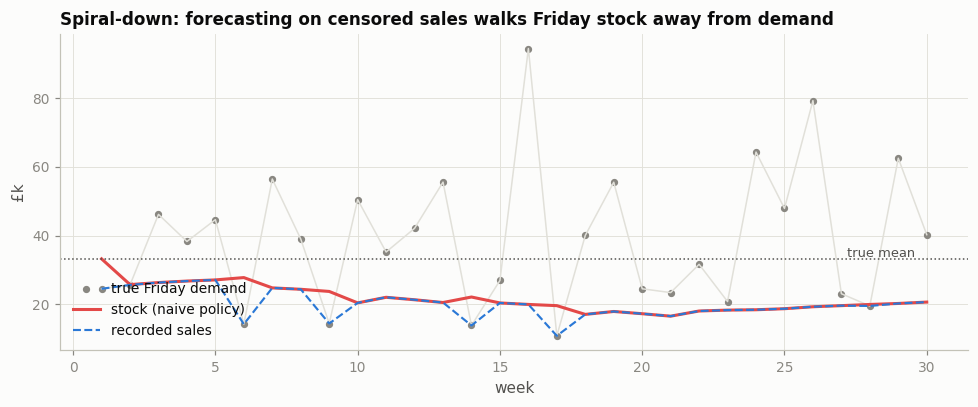

Lost Friday sales over 30 weeks: £567k -> ~£24,401 of margin at 430bps — and the P&L never shows it as a line item.


In [3]:
fig, ax = plt.subplots(figsize=(9, 3.8))
wk = fri.week + 1
ax.plot(wk, fri.demand / 1000, color=C["grid"], lw=1, label="_")
ax.scatter(wk, fri.demand / 1000, s=14, color=C["muted"], label="true Friday demand")
ax.plot(wk, fri.stock / 1000, color=C["red"], lw=2, label="stock (naive policy)")
ax.plot(wk, fri.sales / 1000, color=C["blue"], lw=1.4, ls="--", label="recorded sales")
ax.axhline(true_mean[4] / 1000, color=C["ink2"], lw=1, ls=":")
ax.text(WEEKS - 0.4, true_mean[4] / 1000 + 0.6, "true mean", fontsize=8.5,
        color=C["ink2"], ha="right")
ax.set_xlabel("week"); ax.set_ylabel("£k")
ax.set_title("Spiral-down: forecasting on censored sales walks Friday stock away from demand")
ax.legend(loc="lower left")
plt.tight_layout(); plt.show()

lost = (fri.demand - fri.sales).sum()
margin_bps = 430
print(f"Lost Friday sales over {WEEKS} weeks: £{lost/1000:,.0f}k "
      f"-> ~£{lost * margin_bps / 1e4:,.0f} of margin at {margin_bps}bps — "
      "and the P&L never shows it as a line item.")

## 3. The fix: treat stocked-out days as right-censored

On a stockout day we know only that demand ≥ stock. The log-likelihood is
`Σ_uncensored log pdf(sales) + Σ_censored log SF(stock)` — a Tobit-style fit.
Recover the weekday means from the SAME corrupted history.

In [4]:
def fit_censored(df, x0=None):
    """MLE of per-weekday lognormal mu (shared sigma) under right-censoring.
    Vectorised likelihood + L-BFGS-B so it can run inside a weekly loop."""
    dow = df.dow.to_numpy()
    out = df.out.to_numpy(bool)
    log_sales = np.log(df.sales.to_numpy()[~out])
    log_stock = np.log(df.stock.to_numpy()[out])
    d_unc, d_cen = dow[~out], dow[out]

    def nll(theta):
        mus, sig = theta[:7], abs(theta[7]) + 1e-6
        z = (log_sales - mus[d_unc]) / sig
        ll = (-np.log(sig) - 0.5 * z**2).sum()               # lognormal pdf core
        ll += stats.norm.logsf((log_stock - mus[d_cen]) / sig).sum()
        return -ll

    if x0 is None:
        x0 = np.concatenate([np.log(df.groupby("dow").sales.mean().to_numpy()), [0.3]])
    res = minimize(nll, x0, method="L-BFGS-B", options={"maxiter": 300})
    mus, sig = res.x[:7], abs(res.x[7])
    return np.exp(mus + sig**2 / 2), sig, res.x

naive_est = h.groupby("dow").sales.mean().to_numpy()
cens_est, sig_hat, _ = fit_censored(h)

cmp = pd.DataFrame({"dow": DOW, "true_mean_k": true_mean / 1000,
                    "naive_k": naive_est / 1000, "censored_MLE_k": cens_est / 1000})
print(cmp.round(1).to_string(index=False))
print(f"\nFriday: naive understates by {1 - naive_est[4]/true_mean[4]:.0%}; "
      f"censored MLE is within {abs(cens_est[4]/true_mean[4] - 1):.1%} of truth "
      f"(sigma_hat {sig_hat:.2f} vs true {SIGMA}).")
print("Note Tuesday/Sunday: stock collapsed so far that nearly every day is "
      "censored — the information simply isn't in the data. The fix there is "
      "operational: a deliberate over-stock probe week to restore identification "
      "(the ops version of a randomised exploration stream).")

dow  true_mean_k  naive_k  censored_MLE_k
Mon         15.5     11.5            17.3
Tue         14.4      5.1             9.2
Wed         15.5     11.2            16.8
Thu         18.8     12.9            19.5
Fri         33.2     19.9            31.0
Sat         26.6     17.1            24.6
Sun         10.0      4.8             8.8

Friday: naive understates by 40%; censored MLE is within 6.7% of truth (sigma_hat 0.42 vs true 0.45).
Note Tuesday/Sunday: stock collapsed so far that nearly every day is censored — the information simply isn't in the data. The fix there is operational: a deliberate over-stock probe week to restore identification (the ops version of a randomised exploration stream).


## 4. Arrest the spiral: same policy, censored-aware forecast

Friday stockout rate, weeks 16-30:  naive 87%  vs censored-aware 53%
Friday stock at week 30:  naive £21k  vs censored-aware £38k  (true mean £33k)


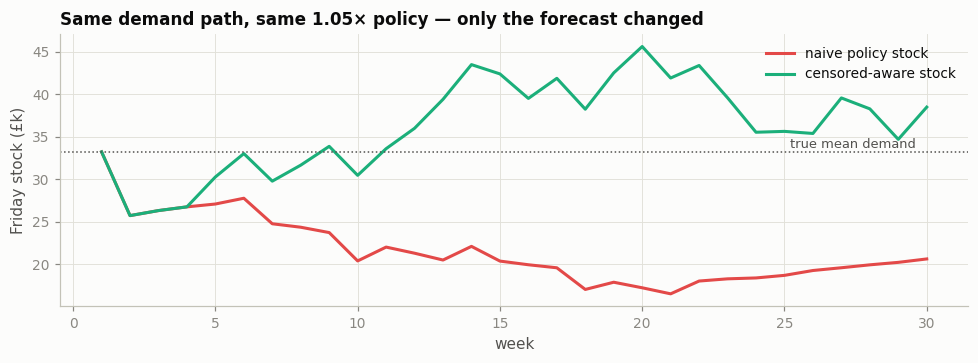

In [5]:
history2 = []
stock = true_mean * 1.0
rng2 = np.random.default_rng(3)          # same demand path as the naive run
warm = None

for w in range(WEEKS):
    for d in range(7):
        dem = draw_demand(d, rng2)
        sales = min(dem, stock[d])
        history2.append((w, d, stock[d], sales, dem > stock[d], dem))
    h2 = pd.DataFrame(history2, columns=["week", "dow", "stock", "sales", "out", "demand"])
    if w >= 3:
        est, _, warm = fit_censored(h2[h2.week > w - 12], x0=warm)
        stock = 1.05 * est
    else:
        stock = (1.05 * h2[h2.week > w - 4].groupby("dow").sales.mean()).to_numpy()

h2 = pd.DataFrame(history2, columns=["week", "dow", "stock", "sales", "out", "demand"])
fri2 = h2[h2.dow == 4]
print(f"Friday stockout rate, weeks 16-30:  naive {fri[fri.week >= 15]['out'].mean():.0%}"
      f"  vs censored-aware {fri2[fri2.week >= 15]['out'].mean():.0%}")
print(f"Friday stock at week 30:  naive £{fri.iloc[-1].stock/1000:.0f}k  "
      f"vs censored-aware £{fri2.iloc[-1].stock/1000:.0f}k  "
      f"(true mean £{true_mean[4]/1000:.0f}k)")

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(fri.week + 1, fri.stock / 1000, color=C["red"], lw=2, label="naive policy stock")
ax.plot(fri2.week + 1, fri2.stock / 1000, color=C["aqua"], lw=2,
        label="censored-aware stock")
ax.axhline(true_mean[4] / 1000, color=C["ink2"], lw=1, ls=":")
ax.text(WEEKS - 0.4, true_mean[4] / 1000 + 0.5, "true mean demand",
        fontsize=8.5, color=C["ink2"], ha="right")
ax.set_xlabel("week"); ax.set_ylabel("Friday stock (£k)")
ax.set_title("Same demand path, same 1.05× policy — only the forecast changed")
ax.legend()
plt.tight_layout(); plt.show()

## 5. Only now, pricing — and carefully

Suppose cash logistics genuinely cap Friday stock below true demand. A small
Friday spread premium shifts *some* demand to Thursday. Price the smoothing —
then read the Consumer Duty caution.

In [6]:
CAP = 28_000                       # hard Friday cash cap (van capacity, insurance)
excess = max(true_mean[4] - CAP, 0)
print(f"True Friday demand £{true_mean[4]/1000:.0f}k vs cap £{CAP/1000:.0f}k "
      f"-> structural excess £{excess/1000:.1f}k/Friday")

# cross-day substitution: +25bps Friday premium, ~20% of marginal demand shifts
PREMIUM_BPS, SHIFT = 25, 0.20
shifted = excess * SHIFT
lost_after = excess - shifted
base_margin = 430
rev_now = CAP * base_margin / 1e4                      # capped Friday, no premium
rev_priced = (CAP * (base_margin + PREMIUM_BPS) / 1e4  # premium on Friday sales
              + shifted * base_margin / 1e4)           # recovered on Thursday
print(f"Friday margin without smoothing: £{rev_now:,.0f}; with +{PREMIUM_BPS}bps "
      f"premium & Thursday recovery: £{rev_priced:,.0f}  "
      f"(+{rev_priced/rev_now - 1:.1%})")
print("\nBUT: the Friday walk-up customer is captive and convenience-driven — "
      "surge-pricing them is a Consumer Duty fair-value risk (PRIN 2A).")
print("Order of attack: 1) fix the forecast (free), 2) fix replenishment "
      "(cash logistics), 3) price only the residual, modestly, with the "
      "fair-value assessment updated BEFORE the change ships.")

True Friday demand £33k vs cap £28k -> structural excess £5.2k/Friday
Friday margin without smoothing: £1,204; with +25bps premium & Thursday recovery: £1,319  (+9.5%)

BUT: the Friday walk-up customer is captive and convenience-driven — surge-pricing them is a Consumer Duty fair-value risk (PRIN 2A).
Order of attack: 1) fix the forecast (free), 2) fix replenishment (cash logistics), 3) price only the residual, modestly, with the fair-value assessment updated BEFORE the change ships.


## The 60-second answer

> "Primarily an ops and forecasting problem with a pricing dimension —
> and the first mistake to avoid is treating recorded sales as demand.
> Friday sales at a stocked-out branch are censored: in this simulation the
> naive forecast understates true Friday demand by around forty percent, and worse,
> it spirals — under-forecast leads to under-stocking leads to more censoring,
> so the system walks the stock down while demand never moved. I'd use the
> stockout timestamps to fit a censored-likelihood model, which recovers true
> Friday demand to within a few percent from the same corrupted history, and
> feeding that back into the same replenishment policy arrests the spiral
> completely.
>
> Pricing only enters if we genuinely can't supply — a hard cash-logistics
> cap. Then a modest Friday premium that shifts some demand to Thursday is
> worth a few percent of Friday margin. But I'd be cautious: the Friday
> walk-up customer is captive and convenience-driven, so surge-pricing them
> is a fair-value risk under Consumer Duty. Fix the forecast first — it's
> free — then the logistics, and price only the residual."

### What I'd say if pushed deeper

1. **"What if stockout timestamps aren't recorded?"** — Then infer them:
   days where sales ≈ round stock figures, or where late-day transactions
   vanish, are candidate censored days. Intra-day till data makes this much
   sharper — that's a data-engineering ask I'd raise in week one.
2. **"Doesn't lost Friday demand just walk to the branch next door?"** —
   Some does, which softens the network P&L cost but *worsens* the
   measurement problem: neighbouring branches' Friday sales are inflated by
   my stockout, which is exactly the interference problem from the
   geo-experiment design (N1). Censoring and spillover have to be modelled
   together in a dense estate.
3. **Honest limitation.** The Tobit fit assumes the demand distribution's
   *shape* (log-normal, stable sigma). If Fridays are bimodal — regulars
   plus holiday spikes — the parametric fit misreads the tail; I'd
   cross-check with a Kaplan-Meier-style non-parametric estimate before
   committing cash-van schedules to it.